In [14]:

import os
import sys
import time
from typing import Tuple

from benchmarks.cluster import uniform_sphere_cluster
import numpy as np
import pandas as pd
from src.triton_mfs import MobMFSTriton
import torch
import torch.profiler as profiler
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from src.gpu_nbody_mob import Mob_Nbody_Torch

torch.set_float32_matmul_precision('high')

if not os.path.exists("data/points") and os.path.exists("../data/points"):
    os.chdir("..")
print(f"Notebook cwd: {os.getcwd()}")
os.environ['TORCH_COMPILE_DISABLE'] = '1'

# Paper-ready typography defaults for every Matplotlib figure in this notebook.
PAPER_FONT_SIZES = {
    "font.size": 24,
    "axes.labelsize": 30,
    "axes.titlesize": 28,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 24,
    "figure.titlesize": 32,
}
plt.rcParams.update(PAPER_FONT_SIZES)
from matplotlib.ticker import FormatStrFormatter

Notebook cwd: /mnt/ffs24/home/khanmd/pinn-stokes


In [2]:
VOL_FRAC = 0.10
NUM_PARTICLES = 300
CENTER_XY = False

mob_gpu = Mob_Nbody_Torch(
    shape="sphere",
    self_nn_path="data/models/self_interaction_model.pt",
    two_nn_path="data/models/combined_2body.wt",
    nbody_nn_path="data/models/nbody_cross_tmp.wt",
    near_field_2b="nn",
    far_field_2b="rpy",
    near_far_switch=6.0,
)


In [3]:

def make_periodic(centers, L, three_d=False, normalize=False, mean_sub=False):
    x, y, z = centers[:, 0], centers[:, 1], centers[:, 2]
    fx = -np.sin(x / L) * np.cos(y / L)
    fy = np.cos(x / L) * np.sin(y / L)
    if three_d:
        fz = -np.sin(z / L) * np.cos(x / L)
    else:
        fz = np.zeros_like(fx)
    F = np.stack([fx, fy, fz], axis=1).astype(np.float64)
    if mean_sub:
        F = F - F.mean(axis=0, keepdims=True)
    if normalize:
        norms = np.linalg.norm(F, axis=1, keepdims=True)
        mask = norms > 1e-8
        F_norm = F.copy()
        np.divide(F, norms, out=F_norm, where=mask)
        F = F_norm
    return F

def make_vertical_split(centers, normalize=False, mean_sub=False):
    x = centers[:, 0]
    x_mid = 0.5 * (x.min() + x.max())
    fx = np.zeros_like(x)
    fy = np.where(x < x_mid, 1.0, -1.0)
    fz = np.zeros_like(x)
    F = np.stack([fx, fy, fz], axis=1).astype(np.float64)
    if mean_sub:
        F = F - F.mean(axis=0, keepdims=True)
    if normalize:
        norms = np.linalg.norm(F, axis=1, keepdims=True)
        mask = norms > 1e-8
        F_norm = F.copy()
        np.divide(F, norms, out=F_norm, where=mask)
        F = F_norm
    return F

def sedimenting_force(centers, normalize=True, mean_sub=False):
    fx = np.zeros_like(centers[:, 0])
    fy = np.zeros_like(centers[:, 1])
    fz = -1.0 * np.ones_like(centers[:, 2])
    F = np.stack([fx, fy, fz], axis=1).astype(np.float64)
    if mean_sub:
        F = F - F.mean(axis=0, keepdims=True)
    if normalize:
        norms = np.linalg.norm(F, axis=1, keepdims=True)
        mask = norms > 1e-8
        F_norm = F.copy()
        np.divide(F, norms, out=F_norm, where=mask)
        F = F_norm
    return F

def _compute_error_stats(predicted, velocity):
    def compute_subset(pred, truth, prefix=""):
        diff = truth - pred

        rmse = np.sqrt(np.mean(np.mean(diff ** 2, axis=1)))
        ref_rms = np.sqrt(np.mean(np.mean(truth ** 2, axis=1)))

        if ref_rms < 1e-12:
            rel_rmse = 0.0
        else:
            rel_rmse = (rmse / ref_rms) * 100

        mae = np.mean(np.linalg.norm(diff, axis=1))

        v_norms = np.linalg.norm(truth, axis=1)
        mean_v_norm = np.mean(v_norms)
        if mean_v_norm < 1e-12:
            rel_mae = 0.0
        else:
            rel_mae = (mae / mean_v_norm) * 100

        with np.errstate(divide="ignore", invalid="ignore"):
            element_rel = np.linalg.norm(diff, axis=1) / v_norms
            element_rel = np.nan_to_num(element_rel)

        max_rel_rmse = np.max(element_rel) * 100

        p = f"{prefix}_" if prefix else ""
        return {
            f"{p}rmse": rmse,
            f"{p}rel_rmse": rel_rmse,
            f"{p}mae": mae,
            f"{p}rel_mae": rel_mae,
            f"{p}max_rel_rmse": max_rel_rmse,
            f"{p}_NORM": ref_rms,
        }

    def compute_linear_directional_metrics(pred, truth):
        eps = 1e-12
        min_speed_true = 1e-8

        speed_true = np.linalg.norm(truth, axis=1)
        speed_pred = np.linalg.norm(pred, axis=1)

        speed_error = speed_pred - speed_true
        mean_speed_error = float(np.mean(speed_error))

        valid = speed_true > min_speed_true
        if not np.any(valid):
            return {
                "linear_speed_error": mean_speed_error,
                "linear_angle_error_deg": np.nan,
                "linear_parallel_error": np.nan,
                "linear_perp_error": np.nan,
            }

        truth_valid = truth[valid]
        pred_valid = pred[valid]
        speed_true_valid = speed_true[valid]
        speed_pred_valid = speed_pred[valid]

        unit_true = truth_valid / (speed_true_valid[:, None] + eps)
        unit_pred = pred_valid / (speed_pred_valid[:, None] + eps)

        cos_sim = np.sum(unit_true * unit_pred, axis=1)
        cos_sim = np.clip(cos_sim, -1.0, 1.0)
        angle_error_deg = np.degrees(np.arccos(cos_sim))

        e = pred_valid - truth_valid
        e_parallel_scalar = np.sum(e * unit_true, axis=1)
        e_parallel_vector = e_parallel_scalar[:, None] * unit_true
        e_perp_vector = e - e_parallel_vector
        e_perp_norm = np.linalg.norm(e_perp_vector, axis=1)

        return {
            "linear_speed_error": mean_speed_error,
            "linear_angle_error_deg": float(np.mean(angle_error_deg)),
            "linear_parallel_error": float(np.mean(e_parallel_scalar)),
            "linear_perp_error": float(np.mean(e_perp_norm)),
        }

    stats = {}
    stats.update(compute_subset(predicted, velocity))
    stats.update(compute_subset(predicted[:, :3], velocity[:, :3], "linear"))
    stats.update(compute_linear_directional_metrics(predicted[:, :3], velocity[:, :3]))
    stats.update(compute_subset(predicted[:, 3:], velocity[:, 3:], "angular"))
    return stats

def _compute_particle_rmse(
    predicted: np.ndarray,
    velocity: np.ndarray,
    linear_only: bool = True,
    ignore_magntiude_below: float = 1e-8,
) -> np.ndarray:
    """Per-particle relative RMSE (%) with per-particle RMS normalization."""
    if linear_only:
        # In-plane RMSE for the x-y plane where the force field is applied.
        target = velocity[:, :3]
        diff = target - predicted[:, :3]
    else:
        target = velocity
        diff = target - predicted
    rmse = np.sqrt(np.mean(diff * diff, axis=1))
    ref_rms = np.sqrt(np.mean(target * target, axis=1))
    return np.where(ref_rms > ignore_magntiude_below, (rmse / ref_rms) * 100.0, 0.0)


def uniform_sphere_cluster_xy(
    volume_fraction: float,
    num_particles: int,
    radius: float = 1.0,
    max_attempts: int = 20000,
    seed: int | None = 42,
) -> np.ndarray:
    """2D non-overlapping placement on z=0 using area fraction for bbox sizing."""
    rng = np.random.default_rng(seed)
    disk_area = np.pi * radius ** 2
    total_disk_area = num_particles * disk_area
    bbox_area = total_disk_area / volume_fraction
    bbox_side = bbox_area ** 0.5
    bbox_half = 0.5 * bbox_side

    min_separation = 0.1  # match uniform_sphere_cluster
    positions = np.zeros((num_particles, 3), dtype=np.float64)
    if num_particles > 0:
        positions[0] = 0.0

    for i in range(1, num_particles):
        attempts = 0
        while attempts < max_attempts:
            pos_xy = rng.uniform(
                -bbox_half + radius,
                bbox_half - radius,
                size=2,
            )
            if i > 0:
                dxy = positions[:i, :2] - pos_xy[None, :]
                dd = np.linalg.norm(dxy, axis=1)
                if np.all(dd >= 2 * radius + min_separation):
                    positions[i] = np.array([pos_xy[0], pos_xy[1], 0.0])
                    break
            else:
                positions[i] = np.array([pos_xy[0], pos_xy[1], 0.0])
                break
            attempts += 1

        if attempts == max_attempts:
            raise RuntimeError(
                f"Could not place particle {i + 1} without overlap in 2D."
            )

    return positions


cluster created
Bounding box: [10.57305186 10.60544998 10.61218969] [-10.61240137 -10.57541453 -10.61345075]
Period: 23.22564044261935
Loaded geometry: 486 boundary nodes, 425 source points
Converged after 67 iterations (max diff = 9.925011e-09)
Mobility computation time: 24374.12 ms
Computing neighbor pairs for n-body correction...
Module src.hashgrid_neighbors b882eb1 load on device 'cuda:0' took 31.59 ms  (cached)
no of RPY interactions: 84172
no of NN interactions: 5528
[Mob_Nbody] Base velocity compute time: 307.056 ms
[Mob_Nbody] Post-base path time: 121.989 ms


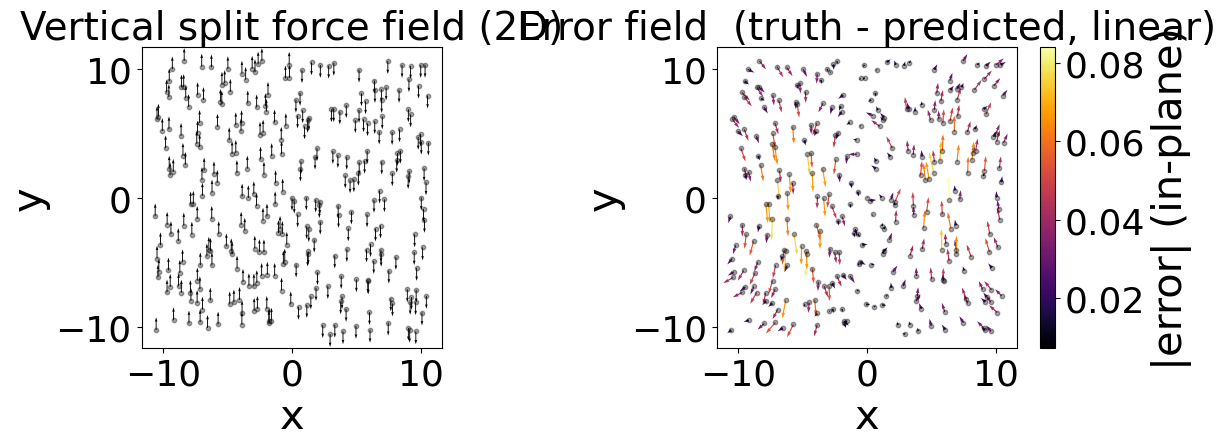

Displayed force field and error field plots inline
Error magnitude — mean: 3.5524e-02, max: 8.4073e-02


In [4]:

if CENTER_XY:
    centers = uniform_sphere_cluster_xy(
        volume_fraction=VOL_FRAC,
        num_particles=NUM_PARTICLES,
        seed=42,
    )
else:
    centers, _ = uniform_sphere_cluster(
        volume_fraction=VOL_FRAC,
        numParticles=NUM_PARTICLES,
        radius=1.0,
        seed=42,
    )

period = np.max(centers.max(axis=0) - centers.min(axis=0)) + 2.0

print("Bounding box:", centers.max(axis=0), centers.min(axis=0))
print("Period:", period)

orientations = np.tile(
    np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float64),
    (NUM_PARTICLES, 1),
)
config = np.concatenate([centers, orientations], axis=1)
F_ext = make_vertical_split(centers, normalize=True, mean_sub=False)
#F_ext *= 2.0

T_ext = np.zeros((NUM_PARTICLES, 3), dtype=np.float64)
forces = np.concatenate([F_ext, T_ext], axis=1)

# Compute truth and prediction for error field
mfs_truth = MobMFSTriton(shape="sphere", acc="Xfine", tol=1e-8)
velocity = mfs_truth.apply(config, forces, viscosity=1.0)
predicted = mob_gpu.apply_cpu(centers, orientations, forces, viscosity=1.0)
error_vec = velocity[:, :3] - predicted[:, :3]  # linear velocity error (3D)
error_mag = np.linalg.norm(error_vec[:, :3], axis=1)
error_field_centers_xy = centers[:, :2].copy()
error_field_vec_xy = error_vec[:, :2].copy()
error_field_mag = error_mag.copy()

# --- Side-by-side: force field (left) and error field (right) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: force field
ax1.quiver(
    centers[:, 0],
    centers[:, 1],
    F_ext[:, 0],
    F_ext[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.003,
)
ax1.scatter(centers[:, 0], centers[:, 1], s=10, c="k", alpha=0.35)
ax1.set_aspect("equal", "box")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Vertical split force field (2D)")

# Right: error direction field, coloured by error magnitude
q = ax2.quiver(
    centers[:, 0],
    centers[:, 1],
    error_vec[:, 0],
    error_vec[:, 1],
    error_mag,
    angles="xy",
    #scale_units="xy",
    scale=None,
    width=0.004,
    cmap="inferno",
)
ax2.scatter(centers[:, 0], centers[:, 1], s=10, c="k", alpha=0.35)
ax2.set_aspect("equal", "box")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Error field  (truth - predicted, linear)")
fig.colorbar(q, ax=ax2, label="|error| (in-plane)")

fig.tight_layout()
plt.show()
print("Displayed force field and error field plots inline")
print(f"Error magnitude — mean: {error_mag.mean():.4e}, max: {error_mag.max():.4e}")


In [5]:
# mfs_truth = MobMFSTriton(shape="sphere", acc="Xfine", tol=1e-8)
# velocity = mfs_truth.apply(config, forces, viscosity=1.0)
# predicted = mob_gpu.apply_cpu(centers, orientations, forces, viscosity=1.0)
# err_values = _compute_error_stats(predicted, velocity)
# import pprint
# pprint.pprint(err_values)

In [6]:
"""Collect simulation data for KDE metrics across random configurations."""

num_particles = 250
base_seed = 42
center_xy = CENTER_XY
volume_fraction = VOL_FRAC
num_configs = 10
force_scale = 1.0
neighbor_cutoff = 6.0

def nearest_neighbor_distance(points_xyz: np.ndarray) -> np.ndarray:
    delta = points_xyz[:, None, :] - points_xyz[None, :, :]
    dist2 = np.sum(delta * delta, axis=2)
    np.fill_diagonal(dist2, np.inf)
    return np.sqrt(np.min(dist2, axis=1)).astype(np.float64)

def neighbor_count_within(points_xyz: np.ndarray, cutoff: float = 6.0) -> np.ndarray:
    assert cutoff > 0.0
    delta = points_xyz[:, None, :] - points_xyz[None, :, :]
    dist2 = np.sum(delta * delta, axis=2)
    np.fill_diagonal(dist2, np.inf)
    return (dist2 <= cutoff * cutoff).sum(axis=1).astype(np.int64)

all_xy = []
all_force_xy = []
all_rel_rmse = []
all_abs_rmse = []
all_velocity_mag = []
all_nearest_neighbor = []

for run_idx in range(num_configs):
    seed = base_seed + run_idx
    if center_xy:
        centers = uniform_sphere_cluster_xy(
            volume_fraction=volume_fraction,
            num_particles=num_particles,
            seed=seed,
        )
    else:
        centers, _ = uniform_sphere_cluster(
            volume_fraction=volume_fraction,
            numParticles=num_particles,
            radius=1.0,
            seed=seed,
        )

    period = np.max(centers.max(axis=0) - centers.min(axis=0)) + 2.0
    orientations = np.tile(
        np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float64),
        (num_particles, 1),
    )
    config = np.concatenate([centers, orientations], axis=1)
    F_ext = make_vertical_split(centers, normalize=True, mean_sub=False)
    #F_ext = sedimenting_force(centers, normalize=True, mean_sub=False)
    F_ext *= force_scale

    T_ext = np.zeros((num_particles, 3), dtype=np.float64)
    forces = np.concatenate([F_ext, T_ext], axis=1)

    velocity = mfs_truth.apply(config, forces, viscosity=1.0)
    predicted = mob_gpu.apply_cpu(centers, orientations, forces, viscosity=1.0)

    diff_xy = velocity[:, :3] - predicted[:, :3]
    abs_rmse = np.sqrt(np.mean(diff_xy * diff_xy, axis=1))
    rel_rmse = _compute_particle_rmse(predicted, velocity, linear_only=True)
    velocity_mag = np.linalg.norm(velocity[:, :3], axis=1)
    nearest_neighbor = neighbor_count_within(centers, cutoff=neighbor_cutoff)

    all_xy.append(centers[:, :2])
    all_force_xy.append(F_ext[:, :2])
    all_rel_rmse.append(rel_rmse)
    all_abs_rmse.append(abs_rmse)
    all_velocity_mag.append(velocity_mag)
    all_nearest_neighbor.append(nearest_neighbor)

    print(
        f"[KDE metrics] run {run_idx + 1}/{num_configs}, seed={seed}, "
        f"mean rel-RMSE={rel_rmse.mean():.4e}%, "
        f"mean abs-RMSE={abs_rmse.mean():.4e}, "
        f"mean |u|={velocity_mag.mean():.4e}, "
        f"mean nn-count={nearest_neighbor.mean():.4e}, "
        f"neighbor_cutoff={neighbor_cutoff:.1f}"
    )

xy = np.concatenate(all_xy, axis=0)
force_xy = np.concatenate(all_force_xy, axis=0)
rel_rmse = np.concatenate(all_rel_rmse, axis=0).astype(np.float64)
abs_rmse = np.concatenate(all_abs_rmse, axis=0).astype(np.float64)
velocity_mag = np.concatenate(all_velocity_mag, axis=0).astype(np.float64)
nearest_neighbor = np.concatenate(all_nearest_neighbor, axis=0).astype(np.float64)

metric_order = [
    "Relative RMSE (%)",
    "RMSE",
    "Velocity Magnitude",
    "Nearest-Neighbor Distance",
]
metric_values = {
    "Relative RMSE (%)": rel_rmse,
    "RMSE": abs_rmse,
    "Velocity Magnitude": velocity_mag,
    "Nearest-Neighbor Distance": nearest_neighbor,
}
cmap_map = {
    "Relative RMSE (%)": "viridis",
    "RMSE": "plasma",
    "Velocity Magnitude": "cividis",
    "Nearest-Neighbor Distance": "magma",
}

print("Collected simulation data for KDE metrics.")

cluster created


Converged after 69 iterations (max diff = 7.852777e-09)
Mobility computation time: 14940.43 ms
Computing neighbor pairs for n-body correction...
no of RPY interactions: 57804
no of NN interactions: 4446
[Mob_Nbody] Base velocity compute time: 4.153 ms
[Mob_Nbody] Post-base path time: 2.777 ms
[KDE metrics] run 1/10, seed=42, mean rel-RMSE=1.0641e+01%, mean abs-RMSE=1.7744e-02, mean |u|=3.1894e-01, mean nn-count=1.7784e+01, neighbor_cutoff=6.0
cluster created
Converged after 64 iterations (max diff = 7.670177e-09)
Mobility computation time: 13859.43 ms
Computing neighbor pairs for n-body correction...
no of RPY interactions: 57702
no of NN interactions: 4548
[Mob_Nbody] Base velocity compute time: 4.032 ms
[Mob_Nbody] Post-base path time: 2.747 ms
[KDE metrics] run 2/10, seed=43, mean rel-RMSE=9.8129e+00%, mean abs-RMSE=1.7673e-02, mean |u|=3.1719e-01, mean nn-count=1.8192e+01, neighbor_cutoff=6.0
cluster created
Converged after 64 iterations (max diff = 8.204663e-09)
Mobility computati

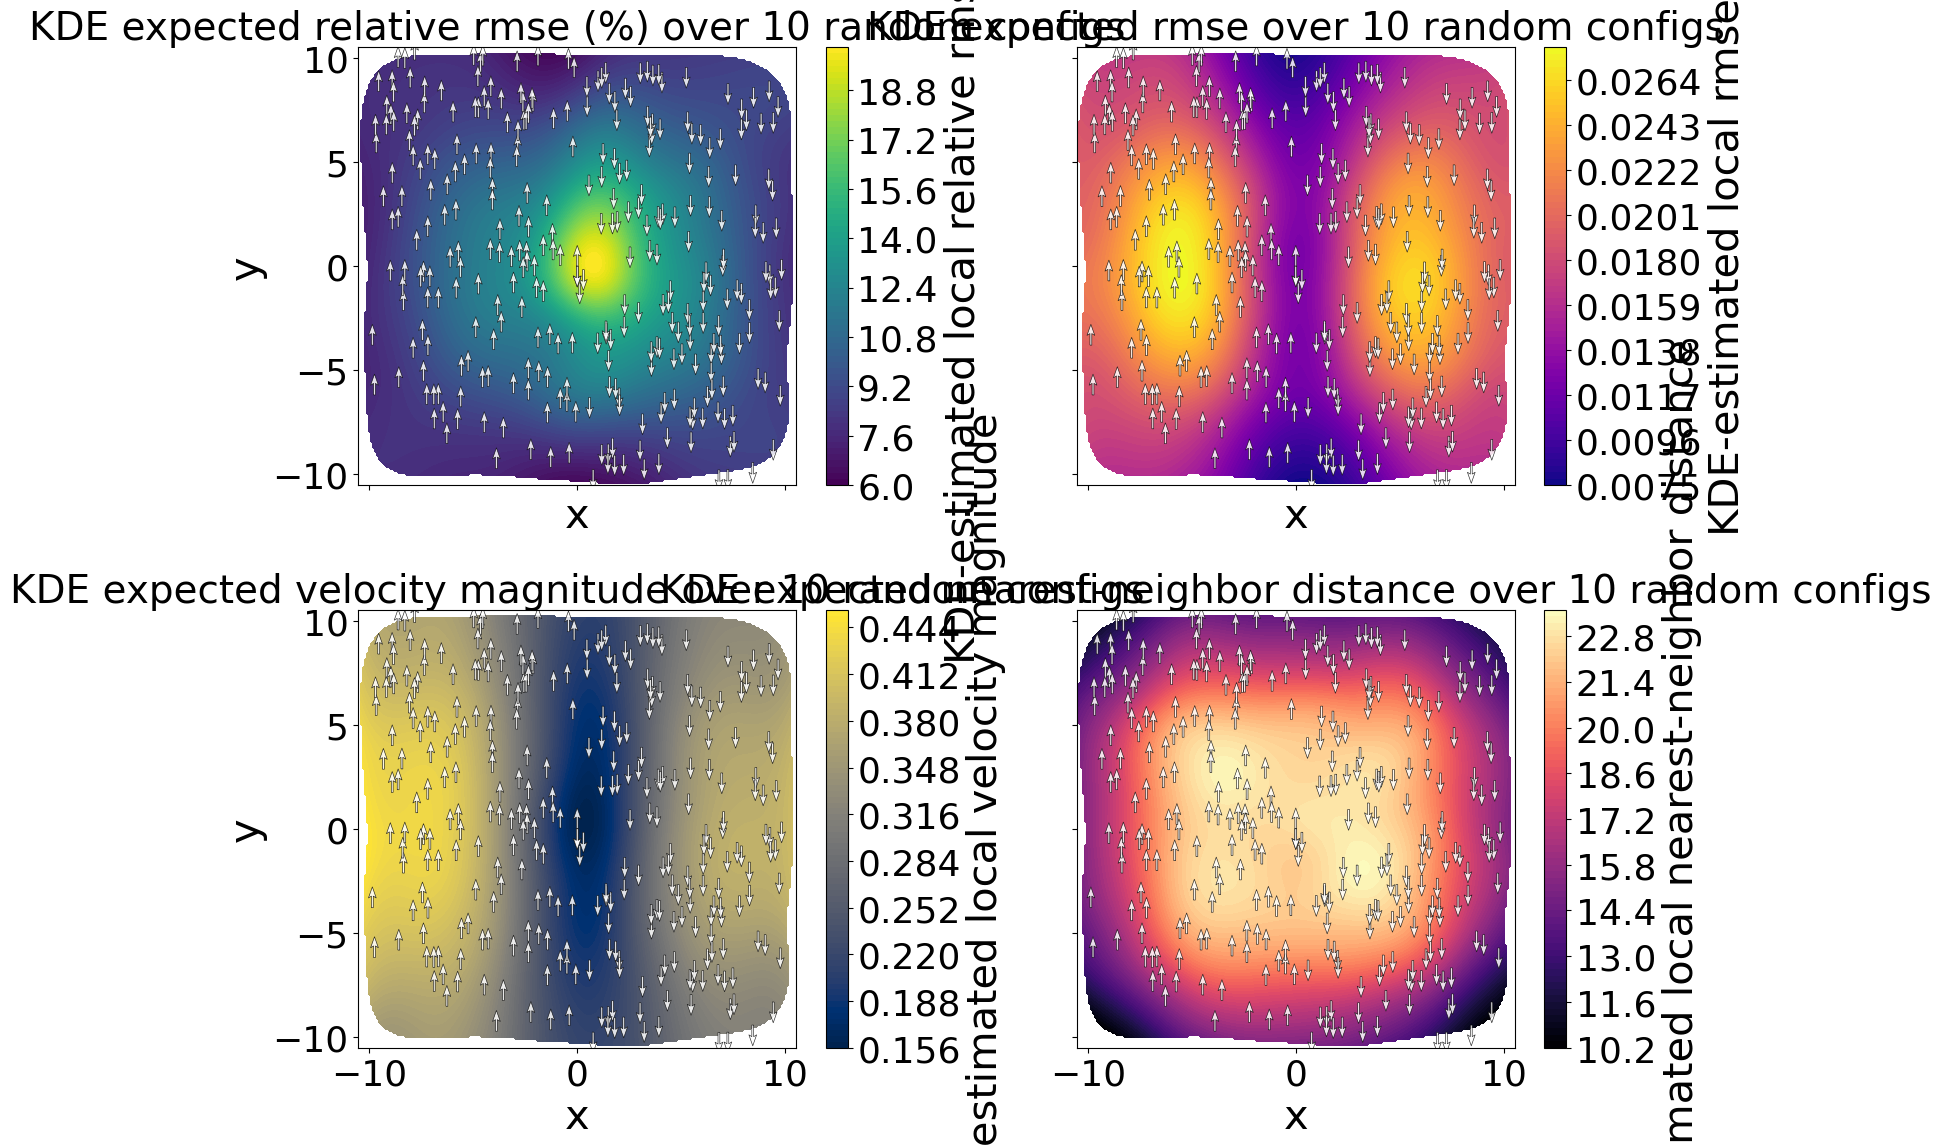

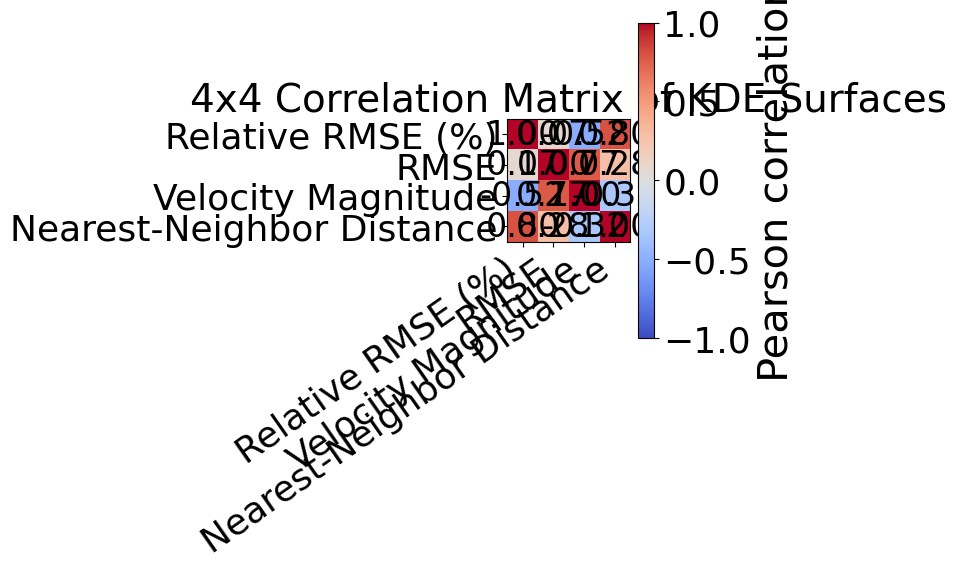

In [7]:
"""Plot 2x2 KDE maps and the 4x4 correlation matrix from collected simulation data."""

x = xy[:, 0]
y = xy[:, 1]
points = np.vstack([x, y])
kde_unweighted = gaussian_kde(points)

x_pad = 0.03 * (x.max() - x.min() + 1e-12)
y_pad = 0.03 * (y.max() - y.min() + 1e-12)
gx = np.linspace(x.min() - x_pad, x.max() + x_pad, 220)
gy = np.linspace(y.min() - y_pad, y.max() + y_pad, 220)
grid_x, grid_y = np.meshgrid(gx, gy)
grid = np.vstack([grid_x.ravel(), grid_y.ravel()])

density = kde_unweighted(grid).reshape(grid_x.shape)

def expected_surface(values: np.ndarray) -> np.ndarray:
    w = np.clip(values, 0.0, None)
    if w.sum() <= 1e-14:
        return np.zeros_like(density)
    kde_weighted = gaussian_kde(points, weights=w)
    density_weighted = kde_weighted(grid).reshape(grid_x.shape)
    return (density_weighted / np.maximum(density, 1e-15)) * w.mean()

valid_density = density[density > 0.0]
density_cutoff = np.quantile(valid_density, 0.08) if valid_density.size else 0.0
mask = density < density_cutoff

surfaces = {}
for name in metric_order:
    surfaces[name] = np.ma.array(expected_surface(metric_values[name]), mask=mask)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes_flat = axes.ravel()

stride = max(1, xy.shape[0] // 280)
for ax, metric_name in zip(axes_flat, metric_order):
    heat = ax.contourf(
        grid_x,
        grid_y,
        surfaces[metric_name],
        levels=75,
        cmap=cmap_map[metric_name],
    )
    ax.quiver(
        xy[::stride, 0],
        xy[::stride, 1],
        force_xy[::stride, 0],
        force_xy[::stride, 1],
        angles="xy",
        scale_units="xy",
        scale=1.0,
        width=0.0042,
        color="white",
        alpha=0.85,
        headwidth=4.2,
        headlength=6.0,
        headaxislength=5.0,
        linewidths=0.45,
        edgecolors="black",
    )
    ax.set_title(f"KDE expected {metric_name.lower()} over {num_configs} random configs")
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    fig.colorbar(heat, ax=ax, label=f"KDE-estimated local {metric_name.lower()}")

axes[0, 0].set_ylabel("y")
axes[1, 0].set_ylabel("y")
fig.tight_layout()
plt.show()

surface_vectors = np.vstack([
    surfaces[name].compressed() for name in metric_order
])

corr = np.full((4, 4), np.nan, dtype=np.float64)
for i in range(4):
    for j in range(4):
        vi = surface_vectors[i]
        vj = surface_vectors[j]
        if vi.size > 1 and np.std(vi) > 1e-12 and np.std(vj) > 1e-12:
            corr[i, j] = float(np.corrcoef(vi, vj)[0, 1])
        elif i == j and vi.size > 0:
            corr[i, j] = 1.0

fig_corr, ax_corr = plt.subplots(figsize=(8, 7))
im = ax_corr.imshow(corr, vmin=-1.0, vmax=1.0, cmap="coolwarm")
ax_corr.set_xticks(range(4), labels=metric_order, rotation=35, ha="right")
ax_corr.set_yticks(range(4), labels=metric_order)
ax_corr.set_title("4x4 Correlation Matrix of KDE Surfaces")

for i in range(4):
    for j in range(4):
        val = corr[i, j]
        label = "nan" if np.isnan(val) else f"{val:.2f}"
        ax_corr.text(j, i, label, ha="center", va="center", color="black", fontsize=24)

fig_corr.colorbar(im, ax=ax_corr, label="Pearson correlation")
fig_corr.tight_layout()
plt.show()

In [8]:

corr_df = pd.DataFrame(corr, index=metric_order, columns=metric_order)

print("Displayed 2x2 KDE metric maps and 4x4 KDE correlation matrix inline")
for name in metric_order:
    vals = metric_values[name]
    print(
        f"[{name}] mean={vals.mean():.4e}, std={vals.std():.4e}, "
        f"min={vals.min():.4e}, max={vals.max():.4e}"
    )
print("[KDE correlation matrix]")
print(corr_df)

Displayed 2x2 KDE metric maps and 4x4 KDE correlation matrix inline
[Relative RMSE (%)] mean=1.0290e+01, std=6.0515e+00, min=7.3962e-01, max=1.0332e+02
[RMSE] mean=1.8206e-02, std=8.8195e-03, min=8.9485e-04, max=5.0296e-02
[Velocity Magnitude] mean=3.2155e-01, std=1.0970e-01, min=1.3630e-02, max=5.7687e-01
[Nearest-Neighbor Distance] mean=1.8323e+01, std=5.8787e+00, min=4.0000e+00, max=3.4000e+01
[KDE correlation matrix]
                           Relative RMSE (%)      RMSE  Velocity Magnitude  \
Relative RMSE (%)                   1.000000  0.069107           -0.522771   
RMSE                                0.069107  1.000000            0.768769   
Velocity Magnitude                 -0.522771  0.768769            1.000000   
Nearest-Neighbor Distance           0.801347  0.277277           -0.323187   

                           Nearest-Neighbor Distance  
Relative RMSE (%)                           0.801347  
RMSE                                        0.277277  
Velocity Magnitude 

In [9]:
NUM_PARTICLES


300

In [10]:
trim_fraction = 0.05

assert "all_rel_rmse" in globals(), "Run the KDE aggregation cell first to populate all_rel_rmse."


def trimmed_mean_rel_rmse(values: np.ndarray, trim_frac: float = 0.05):
    vals = np.asarray(values, dtype=np.float64)
    assert vals.ndim == 1 and vals.size > 0, "Expected a non-empty 1D array of per-particle relative RMSE values."
    trim_count = int(np.floor(trim_frac * vals.size))
    assert 2 * trim_count < vals.size, "Trim fraction is too large for this run size."
    vals_sorted = np.sort(vals)
    trimmed = vals_sorted[trim_count : vals.size - trim_count]
    return float(trimmed.mean()), trim_count, int(trimmed.size)


run_robust_rel_rmse = []
for run_idx, per_particle_rel_rmse in enumerate(all_rel_rmse):
    robust_mean, trim_count, kept = trimmed_mean_rel_rmse(per_particle_rel_rmse, trim_fraction)
    run_robust_rel_rmse.append(robust_mean)
    seed = base_seed + run_idx if "base_seed" in globals() else run_idx
    print(
        f"[Robust rel-RMSE] run {run_idx + 1}/{len(all_rel_rmse)}, seed={seed}, "
        f"trim={trim_fraction:.0%} each tail ({trim_count} low + {trim_count} high), "
        f"kept={kept}, robust mean={robust_mean:.4e}%"
    )

final_robust_avg = float(np.mean(run_robust_rel_rmse))
print(f"[Robust rel-RMSE] final avg over {len(run_robust_rel_rmse)} runs = {final_robust_avg:.4e}%")


[Robust rel-RMSE] run 1/10, seed=42, trim=5% each tail (12 low + 12 high), kept=226, robust mean=9.7529e+00%
[Robust rel-RMSE] run 2/10, seed=43, trim=5% each tail (12 low + 12 high), kept=226, robust mean=9.5923e+00%
[Robust rel-RMSE] run 3/10, seed=44, trim=5% each tail (12 low + 12 high), kept=226, robust mean=9.2061e+00%
[Robust rel-RMSE] run 4/10, seed=45, trim=5% each tail (12 low + 12 high), kept=226, robust mean=1.0070e+01%
[Robust rel-RMSE] run 5/10, seed=46, trim=5% each tail (12 low + 12 high), kept=226, robust mean=8.8533e+00%
[Robust rel-RMSE] run 6/10, seed=47, trim=5% each tail (12 low + 12 high), kept=226, robust mean=1.0158e+01%
[Robust rel-RMSE] run 7/10, seed=48, trim=5% each tail (12 low + 12 high), kept=226, robust mean=1.0161e+01%
[Robust rel-RMSE] run 8/10, seed=49, trim=5% each tail (12 low + 12 high), kept=226, robust mean=1.0098e+01%
[Robust rel-RMSE] run 9/10, seed=50, trim=5% each tail (12 low + 12 high), kept=226, robust mean=9.3029e+00%
[Robust rel-RMSE] r

In [ ]:
# 2x2 export: KDE velocity, RMSE, relative RMSE, and error field
assert "surfaces" in globals(), "Run the KDE surface cell first to populate `surfaces`."
assert "grid_x" in globals() and "grid_y" in globals(), "Run the KDE surface cell first to build the plotting grid."
assert "xy" in globals() and "force_xy" in globals(), "Run the KDE data collection cell first."
assert "error_field_centers_xy" in globals(), "Run the earlier error-field cell first to populate `error_field_centers_xy`."
assert "error_field_vec_xy" in globals(), "Run the earlier error-field cell first to populate `error_field_vec_xy`."
assert "error_field_mag" in globals(), "Run the earlier error-field cell first to populate `error_field_mag`."

combined_pdf_path = "figures/accuracy_deep_dive_fields_2x2.pdf"
os.makedirs("figures", exist_ok=True)

# Author at the size the figure is printed at, so 1 pt here == 1 pt on the page.
# Set FIG_WIDTH_IN to \the\columnwidth of the paper and include it with
#   \includegraphics[width=\columnwidth]{...}   (no height=, no keepaspectratio)
# Any \includegraphics rescaling shrinks strokes into hairlines, which PDF
# viewers clamp to one device pixel -- that is what turns the arrows black.
FIG_WIDTH_IN = 6.5
FIG_HEIGHT_IN = 4.7

AXIS_LABEL_SIZE = 9
TICK_LABEL_SIZE = 7
Y_TICK_LABEL_SIZE = 7
CBAR_LABEL_SIZE = 9
CBAR_TICK_SIZE = 7
PANEL_LABEL_SIZE = 10

# Force is a unit +/-y field, so a sparse sample carries the same information
# as one arrow per particle but leaves the KDE surface visible underneath.
NUM_ARROWS = 150


# (metric, cmap, colorbar label, draw force arrows).  The force direction is
# established once in the velocity panel; repeating it over the two error
# panels only occludes the surface those panels exist to show.
panel_defs = [
    ("Velocity Magnitude", "cividis", "Velocity magnitude", True),
    ("RMSE", "plasma", "RMSE", False),
    ("Relative RMSE (%)", "viridis", "PRMSE (%)", False),
]

fig, axes_grid = plt.subplots(2, 2, figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN), constrained_layout=True)
axes = [axes_grid[0, 0], axes_grid[1, 0], axes_grid[1, 1], axes_grid[0, 1]]
stride = max(1, xy.shape[0] // NUM_ARROWS)

for ax, (metric_name, cmap_name, cbar_label, show_arrows) in zip(axes[:3], panel_defs):
    heat = ax.contourf(
        grid_x,
        grid_y,
        surfaces[metric_name],
        levels=75,
        cmap=cmap_name,
    )
    # Adjacent filled bands leave sub-pixel white seams in vector PDF;
    # stroking each band in its own fill colour closes them.
    heat.set_edgecolor("face")
    if show_arrows:
        ax.quiver(
            xy[::stride, 0],
            xy[::stride, 1],
            force_xy[::stride, 0],
            force_xy[::stride, 1],
            angles="xy",
            scale_units="xy",
            scale=0.55,
            width=0.0075,
            color="white",
            alpha=0.95,
            headwidth=3.2,
            headlength=4.0,
            headaxislength=3.6,
            linewidths=0.3,
            edgecolors="black",
        )
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("y", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="x", labelsize=TICK_LABEL_SIZE)
    ax.tick_params(axis="y", labelsize=Y_TICK_LABEL_SIZE)
    ax.set_title("")
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    cbar = fig.colorbar(heat, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label(cbar_label, fontsize=CBAR_LABEL_SIZE)
    cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)
    yticks = cbar.ax.get_yticks()

    if cbar_label != "RMSE":
        yticks = [round(tick, 2) for tick in yticks]
    else:
        yticks = [round(tick, 3) for tick in yticks]
    cbar.ax.set_yticks(yticks)

q = axes[3].quiver(
    error_field_centers_xy[:, 0],
    error_field_centers_xy[:, 1],
    error_field_vec_xy[:, 0],
    error_field_vec_xy[:, 1],
    error_field_mag,
    angles="xy",
    scale=None,
    width=0.007,
    cmap="inferno",
)
axes[3].scatter(error_field_centers_xy[:, 0], error_field_centers_xy[:, 1], s=2, c="k", alpha=0.35)
axes[3].set_aspect("equal", "box")
axes[3].set_xlabel("x", fontsize=AXIS_LABEL_SIZE)
axes[3].set_ylabel("y", fontsize=AXIS_LABEL_SIZE)
axes[3].tick_params(axis="x", labelsize=TICK_LABEL_SIZE)
axes[3].tick_params(axis="y", labelsize=Y_TICK_LABEL_SIZE)
axes[3].xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
axes[3].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
axes[3].set_title("")
cbar = fig.colorbar(q, ax=axes[3], fraction=0.046, pad=0.02)
cbar.set_label("|error| (in-plane)", fontsize=CBAR_LABEL_SIZE)
cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)

for ax in axes:
    ax.set_title("")

for ax, tag in [
    (axes_grid[0, 0], "(a)"),
    (axes_grid[0, 1], "(b)"),
    (axes_grid[1, 0], "(c)"),
    (axes_grid[1, 1], "(d)"),
]:
    ax.text(
        0.0,
        1.02,
        tag,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
    )

fig.savefig(combined_pdf_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved 2x2 combined field figure to {combined_pdf_path} "
      f"({FIG_WIDTH_IN}x{FIG_HEIGHT_IN} in, include at width=\\columnwidth with no height override).")
